In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import re
from collections import OrderedDict
import importlib
from tqdm.auto import tqdm
import random
import math

import fetch_dataset
importlib.reload(fetch_dataset)
from fetch_dataset import PreprocessedCalciumDataset, calcium_collate_fn

import scipy.ndimage as ndimage

In [2]:
import os
import glob
import pydicom
import numpy as np
import cv2
import xml.etree.ElementTree as ET
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import plistlib
import matplotlib.pyplot as plt
import time

In [3]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

PyTorch Version: 2.11.0+cu126
CUDA Available: True


In [4]:
from monai.losses import DiceFocalLoss, TverskyLoss
from monai.inferers import sliding_window_inference
from monai.transforms import (
    Compose, EnsureChannelFirstd, ScaleIntensityRanged,
    RandCropByPosNegLabeld, RandFlipd, EnsureTyped, MapTransform
)
from monai.networks.nets import UNETR
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete

In [5]:
from segmentation_heads import ViTAdapterUNETRHead
from models.vision_transformer import vit_large_3d  # Standard 3DINO backbone variant

C:\Users\reach\jptrnotebooks\dnmk_project\models\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\reach\jptrnotebooks\dnmk_project\models\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\reach\jptrnotebooks\dnmk_project\models\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [6]:
import warnings
# Forces Python to print EVERY warning, even duplicates
warnings.simplefilter('always', UserWarning)

# CHECK THIS WARNING IF MODEL SUDDENLY STOPS WORKING 
warnings.filterwarnings("ignore", message=".*Num foregrounds 0.*")

# Build Model

In [7]:
class SSL3DSegModel(nn.Module):
    def __init__(self, target_img_size=128, in_channels=1, out_channels=1, weight_path="model_weights/3dino_vit_weights.pth"):
        super().__init__()
        
        print("[*] Step 1: Initializing 3DINO ViT-Large Backbone...")
        # Initialize with size 112 so the structural parameters map perfectly to the checkpoint weights
        backbone = vit_large_3d(
            img_size=112,
            in_chans=in_channels,
            block_chunks=0,
            init_values=1e-5      # Turns on LayerScale slots (1e-5 is the DINOv2 default)
        )
        
        # Load pre-trained weights into the backbone and print out diagnostics
        self._load_backbone_weights(backbone, weight_path)
        
        print("[*] Step 2: Nesting Backbone into ViTAdapterUNETRHead...")
        # Note: target_img_size is passed here so the UNETR CNN decoder sets up its dimensions
        self.model = ViTAdapterUNETRHead(
            feature_model=backbone,
            input_channels=in_channels,
            image_size=target_img_size,
            num_classes=out_channels,
            autocast_ctx=None 
        )
        
        # Apply parameter freezing constraints
        self._freeze_framework()

    def _load_backbone_weights(self, backbone, weight_path):
        if not os.path.exists(weight_path):
            print(f"[-] Warning: {weight_path} not found. Running with random initialization.")
            return

        print("[*] Parsing weight checkpoint parameters...")
        checkpoint = torch.load(weight_path, map_location="cpu")
        state_dict = checkpoint.get("teacher", checkpoint.get("model", checkpoint))

        clean_state_dict = {}
        for k, v in state_dict.items():
            # 1. Strip the generic backbone prefix if present
            k = k.replace("backbone.", "")
            
            # 2. DYNAMIC FIX: Drop the FSDP chunk index dynamically
            # Converts 'blocks.{chunk_idx}.{block_idx}.rest' -> 'blocks.{block_idx}.rest'
            if k.startswith("blocks."):
                parts = k.split(".")
                if len(parts) > 2 and parts[1].isdigit() and parts[2].isdigit():
                    # parts[0] is 'blocks', parts[1] is chunk_idx, parts[2] is true block_idx
                    k = f"blocks.{parts[2]}." + ".".join(parts[3:])
                
            clean_state_dict[k] = v
        
        # Load the weights with strict validation checking
        msg = backbone.load_state_dict(clean_state_dict, strict=False)
        
        # Calculate exactly how many keys inside 'blocks' matched vs missed
        model_block_keys = [k for k in backbone.state_dict().keys() if k.startswith("blocks.")]
        missing_block_keys = [k for k in msg.missing_keys if k.startswith("blocks.")]
        successful_matches = len(model_block_keys) - len(missing_block_keys)

        print("\n" + "="*50)
        print("          WEIGHT LOADING DIAGNOSTIC REPORT          ")
        print("="*50)
        print(f"[+] Core Transformer Blocks Matched:   {successful_matches} / {len(model_block_keys)}")
        print(f"[-] Total Missing Keys (Decoder layers): {len(msg.missing_keys)}")
        print(f"[!] Total Unexpected Keys (Discarded):   {len(msg.unexpected_keys)}")
        print("="*50)

        # Surgical audit of what exactly was rejected inside 'blocks'
        unexpected_blocks = [k for k in msg.unexpected_keys if k.startswith("blocks.")]
        if len(unexpected_blocks) > 0:
            print(f"\n[!] Note: {len(unexpected_blocks)} specific sub-keys inside 'blocks' were discarded.")
            print("    Sample of discarded sub-keys:")
            for k in unexpected_blocks[:6]:
                print(f"      -> {k}")

    def _freeze_framework(self):
        print("[*] Applying parameter freezing strategy...")
        for param in self.parameters():
            param.requires_grad = False
            
        for name, param in self.named_parameters():
            # 1. Keep the entire UNETR upsampling decoder active
            if any(k in name for k in ["encoder", "decoder", "out"]):
                param.requires_grad = True
            # 2. Keep the adapter and cross-attention routing paths active
            if "feature_model.adapter" in name or "feature_model.level_embed" in name:
                param.requires_grad = True

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f"[+] Active Trainable Parameters: {trainable:,} / {total:,} ({(trainable/total)*100:.2f}%)")

    def forward(self, x):
        if x.dim() == 4:
            x = x.unsqueeze(1)
        return self.model(x)


In [8]:
'''
# --- QUICK VERIFICATION TEST CHECK ---
if __name__ == "__main__":
    # Test execution using a simulated 3D CT scan volume batch [Batch, Channel, Depth, Height, Width]
    # We feed it a 128x128x128 scan; the backbone will scale its internal embeddings automatically
    dummy_scan = torch.randn(1, 1, 128, 128, 128)
    
    coca_model = SSL3DSegModel(target_img_size=128)
    
    print("[*] Running pipeline validation pass...")
    with torch.no_grad():
        output_mask = coca_model(dummy_scan)
        
    print(f"[+] Output validation success! Output Mask Shape: {output_mask.shape}")

'''

'\n# --- QUICK VERIFICATION TEST CHECK ---\nif __name__ == "__main__":\n    # Test execution using a simulated 3D CT scan volume batch [Batch, Channel, Depth, Height, Width]\n    # We feed it a 128x128x128 scan; the backbone will scale its internal embeddings automatically\n    dummy_scan = torch.randn(1, 1, 128, 128, 128)\n\n    coca_model = SSL3DSegModel(target_img_size=128)\n\n    print("[*] Running pipeline validation pass...")\n    with torch.no_grad():\n        output_mask = coca_model(dummy_scan)\n\n    print(f"[+] Output validation success! Output Mask Shape: {output_mask.shape}")\n\n'

# Data Loading

In [9]:
class EnsureCorrectShaped(MapTransform):
    """Intelligently forces medical tensors to exactly (1, D, H, W)"""
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            tensor = d[key]
            
            # If shape is (D, H, W, 1), drop the trailing useless dimension
            if tensor.ndim == 4 and tensor.shape[-1] == 1:
                tensor = tensor.squeeze(-1)
            
            # If shape is exactly (D, H, W), add the channel to the front
            if tensor.ndim == 3:
                tensor = tensor.unsqueeze(0)
                
            # (If it's already (1, D, H, W), it simply does nothing!)
            
            d[key] = tensor
        return d

In [10]:
overfit_transforms = Compose([
    ScaleIntensityRanged(
        keys=["image"], 
        a_min=130.0, a_max=800.0, 
        b_min=0.0, b_max=1.0, 
        clip=True
    )
])

In [11]:
train_transforms = Compose([
    # --- THE SMART FIX ---
    EnsureCorrectShaped(keys=["image", "label"]),
    EnsureTyped(keys=["image", "label"]),
    
    # 1. THE HU WINDOW
    # ScaleIntensityRanged(
    #     keys=["image"], a_min=130.0, a_max=800.0, 
    #     b_min=0.0, b_max=1.0, clip=True
    # ),
    
    # 2. THE PATCH CROPPER
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(32, 64, 64), 
        pos=0.9, neg=0.1,
        num_samples=2,
        allow_smaller=True
    )
])

In [12]:
val_transforms = Compose([
    EnsureCorrectShaped(keys=["image", "label"]),
    EnsureTyped(keys=["image", "label"]),
    #ScaleIntensityRanged(keys=["image"], a_min=130.0, a_max=800.0, b_min=0.0, b_max=1.0, clip=True),
    # If your dataset returns numpy arrays, ensure they become tensors:
    # EnsureTyped(keys=["image", "label"]) 
])

In [13]:
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
        
    def __len__(self):
        return len(self.subset)
        
    def __getitem__(self, idx):
        # Fetch the raw, un-transformed patient data
        sample = self.subset[idx]
        # Apply the specific transform for this split
        if self.transform:
            sample = self.transform(sample)
        return sample

In [14]:
# Create the Dataset

data_path = "preprocessed_coca"
train_base = PreprocessedCalciumDataset(data_dir=data_path, transform=train_transforms)
val_base = PreprocessedCalciumDataset(data_dir=data_path, transform=val_transforms)
raw_base = PreprocessedCalciumDataset(data_dir=data_path, transform=None)

In [15]:
import torch

# Grab the first tuple directly from your dataset
img_tensor, label_tensor = raw_base[0]

print("=== DIRECT TENSOR STATS ===")
print(f"Image Shape: {img_tensor.shape}")
print(f"Image Data Type: {img_tensor.dtype}")
print(f"Image Min Value: {img_tensor.min().item():.4f}")
print(f"Image Max Value: {img_tensor.max().item():.4f}")

print("\n=== DIRECT LABEL STATS ===")
print(f"Label Shape: {label_tensor.shape}")
print(f"Label Unique Values: {torch.unique(label_tensor).tolist()}")

=== DIRECT TENSOR STATS ===
Image Shape: torch.Size([1, 64, 128, 128])
Image Data Type: torch.float32
Image Min Value: 0.0000
Image Max Value: 1.0000

=== DIRECT LABEL STATS ===
Label Shape: torch.Size([1, 64, 128, 128])
Label Unique Values: [0, 1]


In [16]:
# Check the first 10 patients
for i in range(min(10, len(train_base))):
    # 1. Catch whatever the dataset returns
    output = train_base[i]
    
    # 2. If it's a list of patches (from your cropper), just look at the first one
    if isinstance(output, list):
        vol, mask = output[0]
    else:
        # If it's just a single volume (e.g., validation set), unpack normally
        vol, mask = output 

    calcium_pixels = mask.sum().item()
    
    if calcium_pixels > 0:
        print(f"Patient {i}: TRUE (Found {calcium_pixels} calcium pixels!)")
    else:
        print(f"Patient {i}: False (No calcium)")

print("Loading REQ_DATASET and splitting into Train/Val/Test...")

Patient 0: False (No calcium)
Patient 1: TRUE (Found 88 calcium pixels!)
Patient 2: TRUE (Found 20 calcium pixels!)
Patient 3: TRUE (Found 31 calcium pixels!)
Patient 4: TRUE (Found 1 calcium pixels!)
Patient 5: TRUE (Found 30 calcium pixels!)
Patient 6: TRUE (Found 2 calcium pixels!)
Patient 7: TRUE (Found 11 calcium pixels!)
Patient 8: TRUE (Found 2 calcium pixels!)
Patient 9: TRUE (Found 2 calcium pixels!)
Loading REQ_DATASET and splitting into Train/Val/Test...


In [17]:
# 1. INSTANTIATE THE BASE DATASETS TWICE (Fast & Memory-Free)
train_base = PreprocessedCalciumDataset(data_dir=data_path, transform=train_transforms)
val_base = PreprocessedCalciumDataset(data_dir=data_path, transform=val_transforms)

# 2. GENERATE SHUFFLED INDICES
dataset_size = len(train_base)
indices = list(range(dataset_size))

# (Optional but recommended) Set a seed so your train/val split is the same every time you run the script
np.random.seed(42)
np.random.shuffle(indices)

# 3. CALCULATE SPLIT SIZES
train_size = int(0.8 * dataset_size)
val_size = int(0.1 * dataset_size)

train_indices = indices[:train_size]
val_indices = indices[train_size : train_size + val_size]
test_indices = indices[train_size + val_size :]

# 4. CREATE THE SUBSETS 
# Train subset pulls from the random-cropping base
train_dataset = Subset(train_base, train_indices)
# Val and Test subsets pull from the deterministic, full-volume base
val_dataset = Subset(val_base, val_indices)
test_dataset = Subset(val_base, test_indices)
raw_test_dataset = Subset(raw_base, test_indices)

# 5. DATALOADERS (Notice the Batch Sizes!)
# Train can handle 2 because the cropper makes the images small
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=0, collate_fn=calcium_collate_fn, pin_memory=True)

# Val and Test MUST be 1, because they are processing massive, full-size CT volumes
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0, collate_fn=calcium_collate_fn, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0, collate_fn=calcium_collate_fn, pin_memory=True)

In [18]:
# Check how many total patients are in your dataset
print(f"Total Patients in Training Set: {len(train_dataset)}")

# Check how many steps (batches) the GPU will process per epoch
print(f"Total Batches per Epoch: {len(train_loader)}")

Total Patients in Training Set: 629
Total Batches per Epoch: 315


In [19]:
# We use raw_base to ensure we are looking at the untouched data
total_patients = len(raw_base)
zero_calcium_count = 0

print(f"--- SCANNING {total_patients} RAW PATIENTS ---")
print("This might take a minute depending on your disk speed...\n")

# Iterate through the entire raw dataset
for i in tqdm(range(total_patients), desc="Scanning patients"):
    # raw_base returns the un-transformed tuple: (image, label)
    _, mask = raw_base[i]
    
    # If the sum of the mask is 0, they have no calcium
    if mask.sum().item() == 0:
        zero_calcium_count += 1

# Calculate the final fractions
fraction = zero_calcium_count / total_patients
percentage = fraction * 100

print("\n--- SCAN COMPLETE ---")
print(f"Zero Calcium Patients: {zero_calcium_count} / {total_patients}")
print(f"Fraction: {fraction:.4f}")
print(f"Percentage: {percentage:.2f}%")

--- SCANNING 787 RAW PATIENTS ---
This might take a minute depending on your disk speed...



Scanning patients:   0%|          | 0/787 [00:00<?, ?it/s]


--- SCAN COMPLETE ---
Zero Calcium Patients: 342 / 787
Fraction: 0.4346
Percentage: 43.46%


In [20]:

# # Run this right after defining train_loader
# print("Fetching one batch to check tensor statistics...")

# for data, targets in train_loader:
#     print("-" * 30)
#     print(f"Data Shape: {data.shape}")
#     print(f"Data Type:  {data.dtype}")
#     print(f"Global Min: {data.min().item():.2f}")
#     print(f"Global Max: {data.max().item():.2f}")
#     print("-" * 30)
    
#     # Break immediately after the first batch
#     break


In [21]:
# Run this right after defining train_loader
print("Fetching one batch to check tensor statistics...")

for data, targets in train_loader:
    print("-" * 30)
    print(f"Data Shape:    {data.shape}")
    print(f"Data Type:     {data.dtype}")
    print(f"Global Min:    {data.min().item():.2f}")
    print(f"Global Max:    {data.max().item():.2f}")
    print("-" * 30)
    print(f"Target Shape:  {targets.shape}")
    print(f"Target Type:   {targets.dtype}")
    
    # Calculate exact calcium pixel counts
    # Using .item() converts a single-value tensor into a standard Python int
    calcium_pixels = int((targets == 1).sum().item())
    total_pixels = int(targets.numel())
    
    print(f"Calcium Pixels (Exact '1's): {calcium_pixels}")
    
    # Safety Check: In case calcium is labeled as '2' or something else
    any_foreground_pixels = int((targets > 0).sum().item())
    if any_foreground_pixels != calcium_pixels:
        print(f"⚠️ WARNING: Found {any_foreground_pixels} total non-zero pixels! Check your class values.")
        
    print(f"Percentage of Calcium:      {(calcium_pixels / total_pixels) * 100:.6f}%")
    print("-" * 30)
    
    # Break immediately after the first batch
    break

Fetching one batch to check tensor statistics...
------------------------------
Data Shape:    torch.Size([4, 1, 32, 64, 64])
Data Type:     torch.float32
Global Min:    0.00
Global Max:    1.00
------------------------------
Target Shape:  torch.Size([4, 1, 32, 64, 64])
Target Type:   torch.int64
Calcium Pixels (Exact '1's): 17
Percentage of Calcium:      0.003242%
------------------------------


# Training

In [22]:
# 1. Initialize the metric
# include_background=False ensures we ONLY score the calcium overlap!
dice_metric = DiceMetric(include_background=False, reduction="mean")

# 2. Initialize the post-processing threshold
# Converts raw logits -> percentages (sigmoid) -> binary 0 or 1 (threshold)
#post_pred = AsDiscrete(threshold=0.7)

In [23]:
# 1. GLOBAL OPTIMIZATION: Enable cuDNN benchmarking
# Since your input size (64, 128, 128) is static, this tells PyTorch to spend 
# a few seconds profiling the best convolution algorithms for your specific GPU.
torch.backends.cudnn.benchmark = True

In [24]:
def train_one_epoch(model, train_loader, optimizer, criterion, device, epoch):
    model.train()
    total_train_loss = 0.0
    
    # Initialize metric for this epoch
    dice_metric = DiceMetric(include_background=False, reduction="mean")
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}", mininterval=2.0, leave=False)
    
    for batch in pbar:
        # 2. Extract Data
        if isinstance(batch, dict):
            data, target = batch["image"], batch["label"]
        else:
            data, target = batch
            
        # 3. GPU OPTIMIZATION: non_blocking=True
        # This allows data transfer to the GPU to happen asynchronously in the background.
        data = data.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        
        # Ensure 5D shape (Batch, Channel, Depth, Height, Width)
        if data.dim() == 4: data = data.unsqueeze(1)
        if target.dim() == 4: target = target.unsqueeze(1)
        
        # 4. GPU OPTIMIZATION: set_to_none=True
        # Faster than setting gradients to zero; completely removes them from memory.
        optimizer.zero_grad(set_to_none=True)

        # --- DATA SANITY TRIPWIRE ---
        
        #print(f"[*] Input Data Range - Min: {data.min().item():.2f} | Max: {data.max().item():.2f}")
        if torch.isnan(data).any() or torch.isinf(data).any():
            print("[-] FATAL: Input data contains NaN or Inf!")
            break
            
        # ----------------------------
        
        # 5. Mixed Precision Forward Pass
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            output = model(data)
            loss = criterion(output.float(), target.float())
            
        # 6. Backward Pass & Scaler Steps
        loss.backward()
        
        # Safe gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Step the optimizer
        optimizer.step()

        for name, p in model.named_parameters():
            if p.grad is not None:
                grad_mean = p.grad.abs().mean().item()
                if math.isnan(grad_mean) or grad_mean == 0.0:
                    print(f"WARNING: Dead/NaN gradient in {name}")
                    break # Stop spamming the terminal, we found the killer
            
        
        # 7. THE BULLETPROOF DICE CALCULATION
        # We use torch.no_grad() so this math doesn't eat up your VRAM
        with torch.no_grad():
            # Apply sigmoid to raw logits to get probabilities (0.0 to 1.0)
            probs = torch.sigmoid(output)
            # Hard threshold at 0.5 to create binary mask
            binary_preds = (probs > 0.5).float()
            # Force target to binary just in case it has weird floating point values
            binary_target = (target > 0.5).float()
            
            # Feed to metric
            dice_metric(y_pred=binary_preds, y=binary_target)
        
        # UI Updates
        total_train_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")
        
    # 8. Calculate Final Metrics for the Epoch
    epoch_loss = total_train_loss / len(train_loader)
    
    # Try to aggregate the Dice score, handle potential NaN if the batch had absolutely 0 calcium
    try:
        epoch_dice = dice_metric.aggregate().item()
    except Exception:
        epoch_dice = 0.0
        
    dice_metric.reset() # Clear memory for next epoch
    
    return epoch_loss, epoch_dice

In [36]:
def validate_one_epoch(
    model, 
    val_loader, 
    criterion, 
    device, 
    roi_size=(64, 128, 128), 
    sw_batch_size=2, 
    threshold=0.5
):
    model.eval()
    total_val_loss = 0.0
    
    # 1. Initialize metric
    dice_metric = DiceMetric(include_background=False, reduction="mean")
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc="Validation", leave=False)
        
        for batch in pbar:
            # 2. Extract Data
            if isinstance(batch, dict):
                data, target = batch["image"], batch["label"]
            else:
                data, target = batch
                
            # 3. GPU OPTIMIZATION: non_blocking=True
            data = data.to(device, non_blocking=True)
            target = target.to(device, non_blocking=True)
            
            # Ensure 5D shape
            if data.dim() == 4: data = data.unsqueeze(1)
            if target.dim() == 4: target = target.unsqueeze(1)
            
            # 4. Mixed Precision Inference
            with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                # Sliding window inference is memory-heavy, so sw_batch_size limits 
                # how many overlapping patches the GPU computes simultaneously.
                output = sliding_window_inference(
                    inputs=data, 
                    roi_size=roi_size, 
                    sw_batch_size=sw_batch_size, 
                    predictor=model,
                    overlap=0.25,
                    #progress=True
                )
                
            # 5. Loss Calculation (Forced to FP32 for stability)
            loss = criterion(output.float(), target.float())
            
            # 6. THE BULLETPROOF DICE CALCULATION
            # Convert raw logits to probabilities and threshold them
            probs = torch.sigmoid(output.float()) 
            binary_preds = (probs > threshold).float()
            binary_target = (target > 0.5).float()
            
            # Update metric for this batch
            dice_metric(y_pred=binary_preds, y=binary_target)
            
            # UI Updates
            total_val_loss += loss.item()
            pbar.set_postfix(val_loss=f"{loss.item():.4f}")
            
    # 7. Calculate Final Metrics for the Epoch
    epoch_loss = total_val_loss / len(val_loader)
    
    try:
        epoch_dice = dice_metric.aggregate().item()
    except Exception:
        epoch_dice = 0.0
        
    dice_metric.reset() # Clear memory
    
    return epoch_loss, epoch_dice

In [26]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)
NUM_CLASSES = 1

cuda


In [27]:
import gc

# Clear out Jupyter variables if they exist
if 'model' in globals(): 
    del model
    print("deleted model...")
if 'optimizer' in globals(): 
    del optimizer
    print("deleted optimizer...")

gc.collect()
torch.cuda.empty_cache()
print("All cleared.")

All cleared.


In [28]:
warnings.filterwarnings(
    "ignore", 
    message=".*torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly.*"
)

In [29]:
# 1. YOUR MODEL
if __name__ == "__main__":
    # Simulate reading multiple 2D CT scans from a folder
    num_slices = 64
    height, width = 128, 128
    
    # 1. Initialize the UNETR wrapper 
    # CRITICAL: img_size must exactly match the (Depth, Height, Width) of the input.
    model = SSL3DSegModel(
        target_img_size=(num_slices, height, width), 
        in_channels=1, 
        out_channels=1, # Set to 1 for binary calcification mask, or change to 3 if you have 3 classes
        weight_path="model_weights/3dino_vit_weights.pth" 
    )
    
    # 2. Generate dummy data: 64 slices of 128x128 pixels
    list_of_2d_layers = [torch.randn(height, width) for _ in range(num_slices)]
    
    # 3. Stack the 2D layers along a new Depth dimension (dim=0)
    # This transforms a list of (H, W) into a single (D, H, W) tensor
    volume_3d = torch.stack(list_of_2d_layers, dim=0)
    
    # 4. Add the Batch dimension -> (Batch, Depth, Height, Width)
    batch_input = volume_3d.unsqueeze(0)
    
    print("Raw Input shape (Batch, Slices, H, W):", batch_input.shape)
    
    # 5. Run the model
    # (The internal x.unsqueeze(1) in the forward pass safely adds the channel dimension)
    y = model(batch_input)
    
    print("Final Output shape (Batch, Classes, D, H, W):", y.shape)

[*] Step 1: Initializing 3DINO ViT-Large Backbone...
[*] Parsing weight checkpoint parameters...

          WEIGHT LOADING DIAGNOSTIC REPORT          
[+] Core Transformer Blocks Matched:   336 / 336
[-] Total Missing Keys (Decoder layers): 0
[!] Total Unexpected Keys (Discarded):   16
[*] Step 2: Nesting Backbone into ViTAdapterUNETRHead...
[*] Applying parameter freezing strategy...
[+] Active Trainable Parameters: 20,998,049 / 349,884,225 (6.00%)
Raw Input shape (Batch, Slices, H, W): torch.Size([1, 64, 128, 128])


C:\Users\reach\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Final Output shape (Batch, Classes, D, H, W): torch.Size([1, 1, 64, 128, 128])


In [30]:
# 2. LOSS

criterion = DiceFocalLoss(
    include_background=True, sigmoid=True, 
    gamma=2.5, alpha=0.9,
    smooth_nr=1e-3, smooth_dr=1e-3 # Prevents the 0/0 NaN on empty patches
)

'''
# Replace DiceFocalLoss with this for your ultra-sparse target
criterion = TverskyLoss(
    sigmoid=True,
    alpha=0.4,  # Low penalty for false positives
    beta=0.6    # Massive penalty for missing the calcium voxels!
)
'''

model.to(DEVICE);
#semicolon suppresses verbose output, kind of like just typing variable name to see its value in jupyter

In [31]:
# 1. Create empty lists to hold the two distinct parameter groups
encoder_adapter_params = []
decoder_head_params = []

# 2. Iterate through all named parameters in your SSL3DSegModel
for name, param in model.named_parameters():
    
    # Skip the frozen DINO backbone entirely (they don't need an optimizer)
    if not param.requires_grad:
        continue
        
    # Route parameters based on the naming logic in your _freeze_framework
    if "feature_model" in name:
        # This catches feature_model.adapter and feature_model.level_embed
        encoder_adapter_params.append(param)
    else:
        # This catches all the UNETR components (encoder, decoder, out)
        decoder_head_params.append(param)

# 3. Initialize AdamW with differential parameter groups
optimizer = torch.optim.AdamW([
    {'params': encoder_adapter_params, 'lr': 1e-5}, # Gentle LR for ViT Adapters
    {'params': decoder_head_params, 'lr': 1e-4}     # Standard LR for UNETR Head
], weight_decay=1e-5)

In [32]:
# --- INITIALIZATION ---
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)
scaler = torch.amp.GradScaler('cuda')
best_val_loss = float('inf')
MAX_EPOCHS = 100
TRAIN_PATCH_SIZE = (64, 128, 128) # Change this to whatever spatial size DINO is expecting!

In [33]:

warnings.filterwarnings("ignore", message=".*Using a non-tuple sequence for multidimensional indexing is deprecated.*")

In [34]:
# --- Setup Overfitting Check Variables Before the Loop ---
best_val_loss = float('inf')
best_val_dice = 0.0  # Optional: If you want to track the best Dice score too
patience = 6        # How many epochs to wait before stopping if overfitting * 5
epochs_no_improve = 0
max_allowed_gap = 0.15 # If val loss is this much higher than train loss, it's memorizing

In [35]:
# --- THE SANITY CHECK CELL ---
# Grab just one batch from the loader
sanity_batch = next(iter(train_loader))
# Unpack by position (tuple index) instead of string keys
imgs = sanity_batch[0]
labels = sanity_batch[1]

print(f"Image Shape: {imgs.shape}") # Should be [Batch, Channel, Depth, Height, Width]
print(f"Label Shape: {labels.shape}") 

# Check if ANY calcium exists in this batch
if labels.max() == 0:
    print("⚠️ WARNING: No calcium found in this batch. Is this expected?")
else:
    print("✅ Calcium successfully loaded!")

Image Shape: torch.Size([4, 1, 32, 64, 64])
Label Shape: torch.Size([4, 1, 32, 64, 64])
✅ Calcium successfully loaded!


In [37]:
print("Starting Training...")

for epoch in range(1, MAX_EPOCHS + 1):
    print(f"\nEpoch [{epoch}/{MAX_EPOCHS}]")
    
    # 1. Train
    avg_train_loss, avg_train_dice = train_one_epoch(
        model=model, 
        train_loader=train_loader, 
        optimizer=optimizer, 
        criterion=criterion, 
        device=DEVICE, 
        epoch=epoch
    )

    print(f"-> Train Loss: {avg_train_loss:.4f} | Train Dice: {avg_train_dice:.4f}")

    # 2. Validate (Assuming your function returns both Loss and Dice now)
    if epoch%5==0:
        avg_val_loss, avg_val_dice = validate_one_epoch(
            model=model, 
            val_loader=val_loader, 
            criterion=criterion, 
            device=DEVICE,
            roi_size=TRAIN_PATCH_SIZE
        )
        
        print(f"-> Val Loss: {avg_val_loss:.4f} | Val Dice: {avg_val_dice:.4f}")
        
        # --- OVERFITTING CHECK 1: The Gap Warning ---
        loss_gap = avg_val_loss - avg_train_loss
        if loss_gap > max_allowed_gap:
            print(f"   [!] WARNING: Val Loss is {loss_gap:.4f} higher than Train Loss. The model is starting to overfit (memorize)!")
    
        # 3. Checkpoint Saver & OVERFITTING CHECK 2: Early Stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0 # Reset the patience counter
            
            # Save the model
            torch.save(model.state_dict(), "best_3d_dino_model.pth")
            print("   [+] New best model saved based on Val Loss!")
            
        else:
            epochs_no_improve += 1
            print(f"   [-] No improvement in Val Loss for {epochs_no_improve} epoch(s).")
            
            # Trigger Early Stopping if we hit the patience limit
            if epochs_no_improve >= patience:
                print(f"\n[🛑] EARLY STOPPING TRIGGERED!")
                print(f"Validation loss hasn't improved in {patience} epochs. Training stopped to prevent severe overfitting.")
                break # Exits the training loop entirely

    # Step the learning rate scheduler
    scheduler.step()

Starting Training...

Epoch [1/100]


Epoch 1:   0%|          | 0/315 [00:00<?, ?it/s]

-> Train Loss: 0.9994 | Train Dice: 0.1693

Epoch [2/100]


Epoch 2:   0%|          | 0/315 [00:00<?, ?it/s]

-> Train Loss: 0.9972 | Train Dice: 0.2324

Epoch [3/100]


...

Epoch 14:   0%|          | 0/315 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



-> Train Loss: 0.5505 | Train Dice: 0.8567


Validation:   0%|          | 0/78 [00:00<?, ?it/s]

-> Val Loss: 0.7371 | Val Dice: 0.5451
   [!] WARNING: Val Loss is 0.1867 higher than Train Loss. The model is starting to overfit (memorize)!
   [-] No improvement in Val Loss for 6 epoch(s).

[🛑] EARLY STOPPING TRIGGERED!
Validation loss hasn't improved in 6 epochs. Training stopped to prevent severe overfitting.


In [38]:
torch.save(model.state_dict(), "best_3d_dino_model.pth")

In [39]:
print("--- DATA STRUCTURE INSPECTION ---")
raw_output = train_base[0]

print(f"1. Overall type of train_base[0]: {type(raw_output)}")

# If it's a list (meaning it already cropped the patches)
if isinstance(raw_output, list):
    print(f"2. Number of patches returned: {len(raw_output)}")
    print(f"3. Type of first item in list: {type(raw_output[0])}")
    
    if isinstance(raw_output[0], tuple):
        img_tensor = raw_output[0][0]
        lbl_tensor = raw_output[0][1]
        print(f"\n--- FIRST PATCH STATS ---")
        print(f"Image Type: {type(img_tensor)}")
        if hasattr(img_tensor, 'shape'): print(f"Image Shape: {img_tensor.shape}")
        print(f"Label Type: {type(lbl_tensor)}")
        if hasattr(lbl_tensor, 'shape'): print(f"Label Shape: {lbl_tensor.shape}")
        if hasattr(lbl_tensor, 'sum'): print(f"Calcium Voxels: {lbl_tensor.sum()}")

# If it's a standard tuple (meaning no patches yet)
elif isinstance(raw_output, tuple):
    print(f"2. Length of tuple: {len(raw_output)}")
    img_tensor = raw_output[0]
    lbl_tensor = raw_output[1]
    print(f"\n--- FULL VOLUME STATS ---")
    if hasattr(img_tensor, 'shape'): print(f"Image Shape: {img_tensor.shape}")
    if hasattr(lbl_tensor, 'shape'): print(f"Label Shape: {lbl_tensor.shape}")
    if hasattr(lbl_tensor, 'sum'): print(f"Calcium Voxels: {lbl_tensor.sum()}")

--- DATA STRUCTURE INSPECTION ---
1. Overall type of train_base[0]: <class 'list'>
2. Number of patches returned: 2
3. Type of first item in list: <class 'tuple'>

--- FIRST PATCH STATS ---
Image Type: <class 'monai.data.meta_tensor.MetaTensor'>
Image Shape: torch.Size([1, 32, 64, 64])
Label Type: <class 'monai.data.meta_tensor.MetaTensor'>
Label Shape: torch.Size([1, 32, 64, 64])
Calcium Voxels: 2


In [ ]:
print("--- PIPELINE FORENSICS ---")

# 1. Grab Patient 0 (We know they have calcium!)
raw_output = train_base[0]

# Pack the tuple (index 0 and 1) into a dictionary for MONAI
test_sample = {
    "image": raw_output[0], 
    "label": raw_output[1]
}

# Helper function to print stats safely
def print_stats(step_name, data):
    img, lbl = data['image'], data['label']
    print(f"{step_name}:")
    print(f"   Image Shape: {img.shape}")
    print(f"   Label Shape: {lbl.shape}")
    print(f"   Calcium Voxels (Sum): {lbl.sum()}\n")

print_stats("1. RAW DATA", test_sample)

# 2. Test EnsureCorrectShaped (Make sure this class is still defined in your notebook!)
t1 = EnsureCorrectShaped(keys=["image", "label"])
test_sample = t1(test_sample)
print_stats("2. AFTER SHAPE FIX", test_sample)

# 3. Test EnsureTyped
t2 = EnsureTyped(keys=["image", "label"])
test_sample = t2(test_sample)
print_stats("3. AFTER TYPING", test_sample)

# 4. Test HU Windowing (ScaleIntensityRanged)
t3 = ScaleIntensityRanged(
    keys=["image"], a_min=130.0, a_max=800.0, 
    b_min=0.0, b_max=1.0, clip=True
)
test_sample = t3(test_sample)
print_stats("4. AFTER HU WINDOWING", test_sample)

# 5. The Cropper Test
print("5. ATTEMPTING CROPPER...")
t4 = RandCropByPosNegLabeld(
    keys=["image", "label"],
    label_key="label",
    spatial_size=(32, 64, 64), 
    pos=0.9, neg=0.1,
    num_samples=2,
    allow_smaller=True
)
try:
    crops = t4(test_sample)
    print("✅ Cropper succeeded without warnings!")
except Exception as e:
    print(f"❌ Cropper crashed: {e}")

# Test model

In [40]:
from monai.inferers import sliding_window_inference

# NOTE: Pass your model instance directly into the function so it doesn't matter what class it is
def test_model(model_path, model, loader, criterion, device, roi_size=(32, 64, 64)):
    print(f"\n--- Starting Evaluation on Test Set ---")
    print(f"Loading best weights from '{model_path}'...")
    
    # Load the best weights into the model we provided
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    total_test_loss = 0.0
    
    with torch.no_grad():
        for batch in loader:
            # 1. Compatibility for both MONAI dicts and standard tuples
            if isinstance(batch, dict):
                data, target = batch["image"], batch["label"]
            else:
                data, target = batch
                
            data, target = data.to(device), target.to(device)
            
            # 2. Ensure 5D dimensions
            if data.dim() == 4:
                data = data.unsqueeze(1)
            if target.dim() == 4:
                target = target.unsqueeze(1)
                
            # 3. SOTA Inference for full volumes
            with torch.amp.autocast('cuda'):
                output = sliding_window_inference(
                    inputs=data, 
                    roi_size=roi_size, 
                    sw_batch_size=4, 
                    predictor=model,
                    overlap=0.5
                )
                
            # 4. FP32 Loss calculation
            loss = criterion(output.float(), target.float())
            total_test_loss += loss.item()
            
    avg_test_loss = total_test_loss / len(loader)
    print(f"FINAL TEST LOSS: {avg_test_loss:.4f}")
    return avg_test_loss

In [41]:
model_path = "best_3d_dino_model.pth"
model.load_state_dict(torch.load(model_path))
model.eval()

SSL3DSegModel(
  (model): ViTAdapterUNETRHead(
    (feature_model): ViTAdapter(
      (vit_model): DinoVisionTransformer3d(
        (patch_embed): PatchEmbed3d(
          (proj): Conv3d(1, 1024, kernel_size=(16, 16, 16), stride=(16, 16, 16))
          (norm): Identity()
        )
        (blocks): ModuleList(
          (0-23): 24 x NestedTensorBlock(
            (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
            (attn): MemEffAttention(
              (qkv): Linear(in_features=1024, out_features=3072, bias=True)
              (attn_drop): Dropout(p=0.0, inplace=False)
              (proj): Linear(in_features=1024, out_features=1024, bias=True)
              (proj_drop): Dropout(p=0.0, inplace=False)
            )
            (ls1): LayerScale()
            (drop_path1): Identity()
            (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        

In [50]:
# Added raw_test_dataset to the arguments!
def visualize_test_loader(model, test_loader, raw_test_dataset, criterion, device="cuda", num_samples=5, roi_size=(32, 64, 64), threshold=0.5):
    model.eval()
    
    print(f"Gathering {num_samples} samples from the test loader...")
    fig, axes = plt.subplots(num_samples, 3, figsize=(18, 6 * num_samples))
    if num_samples == 1: axes = axes.reshape(1, 3)
        
    samples_collected = 0
    dice_metric = DiceMetric(include_background=False, reduction="mean")
    
    with torch.no_grad():
        # Use enumerate so we can perfectly track our index in the raw dataset!
        for batch_idx, batch in enumerate(test_loader):
            if isinstance(batch, dict):
                data, target = batch["image"], batch["label"]
            else:
                data, target = batch
                
            data, target = data.to(device), target.to(device)
            
            if data.dim() == 4: data = data.unsqueeze(1)
            if target.dim() == 4: target = target.unsqueeze(1)
                
            print(f"\nProcessing Patient {samples_collected + 1} / {num_samples}...")
            
            # --- MODEL GETS THE STRICT, BLACK-BACKGROUND DATA ---
            with torch.amp.autocast('cuda'):
                output = sliding_window_inference(
                    inputs=data, roi_size=roi_size, sw_batch_size=2, 
                    predictor=model, overlap=0.25, progress=True
                )

            probs = torch.sigmoid(output.float())
            pred_masks = (probs > threshold).float() 
            binary_target = (target > 0.5).float()
            dice_metric(y_pred=pred_masks, y=binary_target)
            
            patient_loss = criterion(output.float(), target.float()).item()
            
            # --- HUMANS GET THE RAW, GENTLY WINDOWED DATA ---
            # Fetch the exact same patient from the raw dataset
            raw_patient = raw_test_dataset[batch_idx]
            raw_image = raw_patient[0] if isinstance(raw_patient, tuple) else raw_patient["image"]
            
            # Apply a "Visual Window" (-200 to 800) to show soft tissue
            disp_img = torch.clamp(raw_image, min=-200.0, max=800.0)
            # Normalize to 0-1 for Matplotlib
            disp_img = (disp_img - (-200.0)) / (800.0 - (-200.0))
            
            # Convert to numpy arrays
            image_disp = disp_img.squeeze().cpu().numpy()  
            mask_disp = binary_target.squeeze().cpu().numpy() 
            pred_disp = pred_masks.squeeze().cpu().numpy()       
            
            # Smart Slice Selection
            calcium_per_slice = mask_disp.sum(axis=(1, 2))
            best_slice_idx = calcium_per_slice.argmax()
            
            if calcium_per_slice[best_slice_idx] == 0:
                best_slice_idx = image_disp.shape[0] // 2 
            
            gt_pixels_total = binary_target.sum().item()
            pred_pixels_total = pred_masks.sum().item()
            gt_pixels_slice = mask_disp[best_slice_idx].sum()
            pred_pixels_slice = pred_disp[best_slice_idx].sum()
            
            # Plotting
            row = samples_collected
            
            # Plot A: Original CT with Anatomy Visible!
            axes[row, 0].imshow(image_disp[best_slice_idx], cmap='gray')
            axes[row, 0].set_title(f"Patient {samples_collected+1} CT (Slice {best_slice_idx})", fontsize=14)
            axes[row, 0].axis('off')
            
            # Plot B: Ground Truth
            axes[row, 1].imshow(image_disp[best_slice_idx], cmap='gray')
            axes[row, 1].imshow(np.ma.masked_where(mask_disp[best_slice_idx] == 0, mask_disp[best_slice_idx]), cmap='autumn', alpha=0.6, vmin=0, vmax=1)
            axes[row, 1].set_title(f"Ground Truth (Red)\nVol Px: {int(gt_pixels_total)} | Slice Px: {int(gt_pixels_slice)}", fontsize=14)
            axes[row, 1].axis('off')
            
            # Plot C: Model Prediction
            axes[row, 2].imshow(image_disp[best_slice_idx], cmap='gray')
            axes[row, 2].imshow(np.ma.masked_where(pred_disp[best_slice_idx] == 0, pred_disp[best_slice_idx]), cmap='winter', alpha=0.6, vmin=0, vmax=1)
            title_str = f"Model Prediction (Blue)\nLoss: {patient_loss:.4f} | Vol Px: {int(pred_pixels_total)} | Slice Px: {int(pred_pixels_slice)}"
            axes[row, 2].set_title(title_str, fontsize=14, color='darkred')
            axes[row, 2].axis('off')
            
            # Apply the Auto-Zoom we discussed earlier!
            y_coords, x_coords = np.where(mask_disp[best_slice_idx] > 0)
            if len(y_coords) > 0:
                pad = 60
                y_min, y_max = max(0, y_coords.min() - pad), min(image_disp.shape[1], y_coords.max() + pad)
                x_min, x_max = max(0, x_coords.min() - pad), min(image_disp.shape[2], x_coords.max() + pad)
                for col in range(3):
                    axes[row, col].set_xlim(x_min, x_max)
                    axes[row, col].set_ylim(y_max, y_min)

            samples_collected += 1
            if samples_collected >= num_samples:
                break

    plt.tight_layout()
    plt.show()

Gathering 5 samples from the test loader...

Processing Patient 1 / 5...


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.71it/s]



Processing Patient 2 / 5...


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.68it/s]



Processing Patient 3 / 5...


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.43it/s]



Processing Patient 4 / 5...


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.78it/s]



Processing Patient 5 / 5...


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.79it/s]


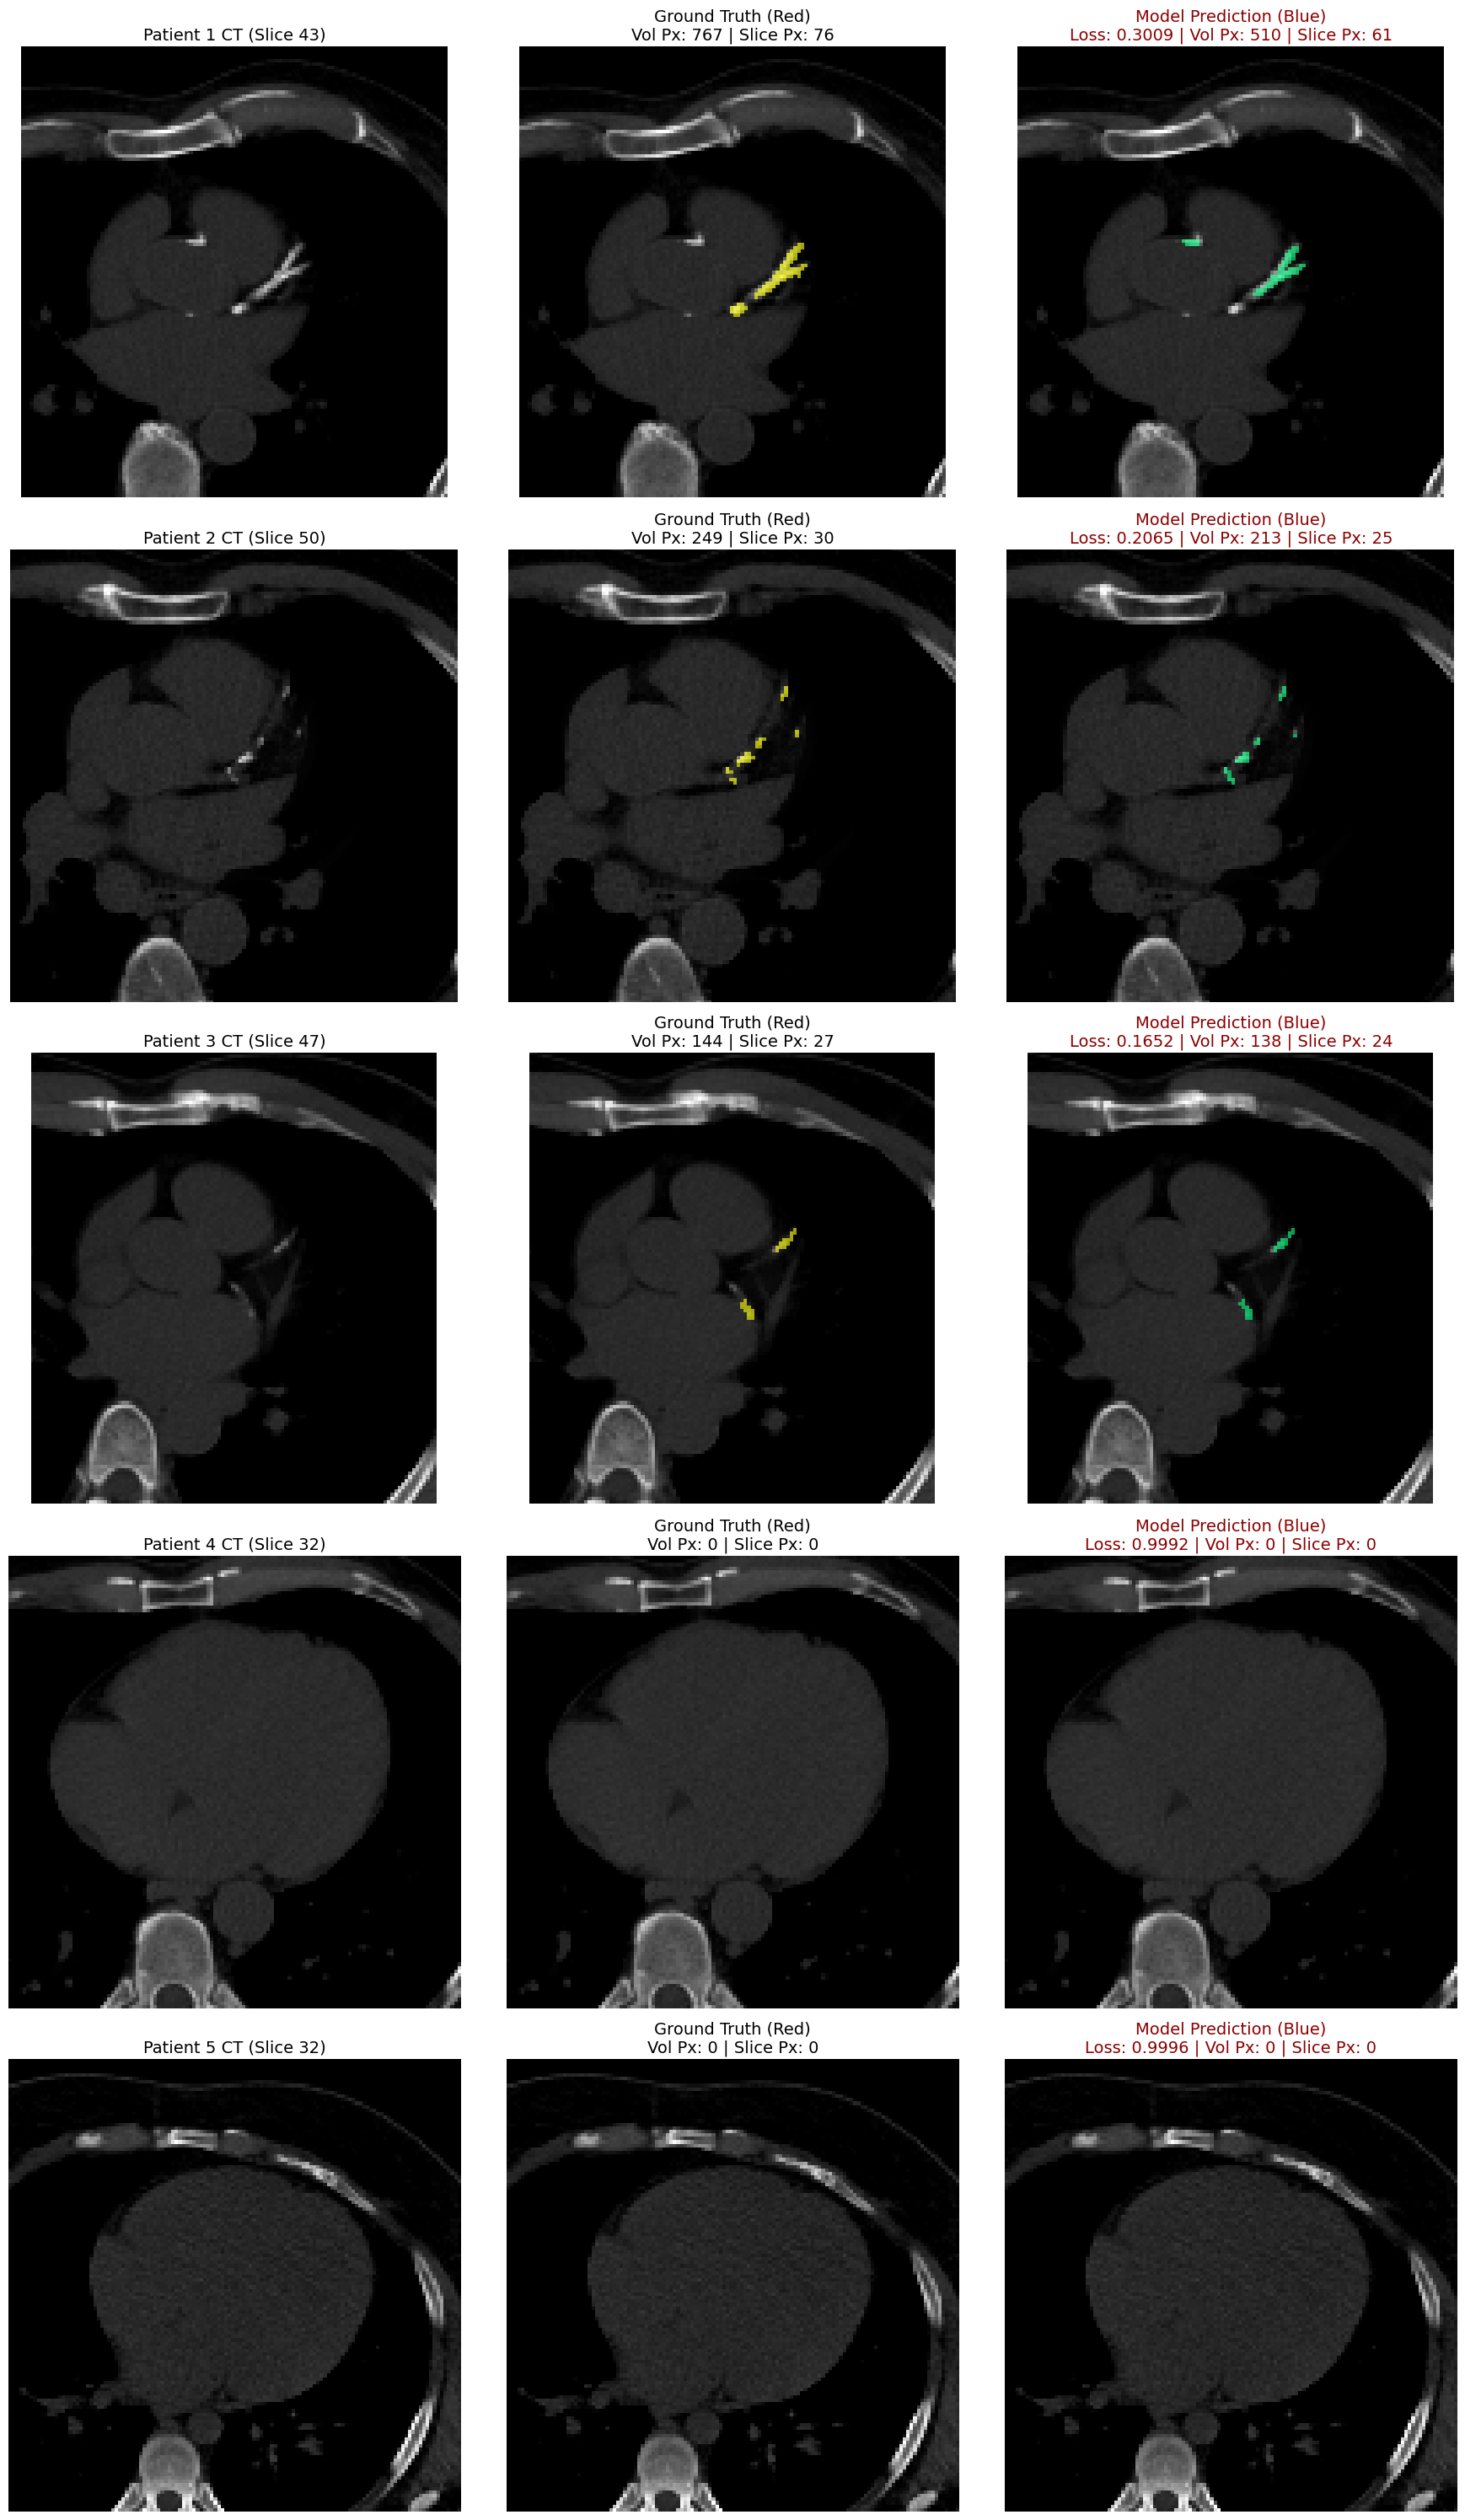

In [51]:
# --- RUN IT HERE ---
# NOTE: Make sure TRAIN_PATCH_SIZE matches whatever roi_size you used in validate_one_epoch
TRAIN_PATCH_SIZE = (64, 128, 128) 

#final_score = test_model("best_3d_dino_model.pth", model, train_loader, criterion, DEVICE, roi_size=TRAIN_PATCH_SIZE)

visualize_test_loader(model, test_loader, raw_test_dataset, criterion, device=DEVICE, num_samples=5, roi_size=TRAIN_PATCH_SIZE)